# Practice 1 – FashionMNIST Classification
## Loss, Optimizer và Training Loop
- Cell 14: Loss Function
- Cell 15: Optimizer
- Cell 16: Training Function
- Cell 17: Run Training
- Cell 18: Plot Loss

Cell 13 bên dưới là phần **tạm thời** (data + model đơn giản) để notebook chạy độc lập được ngay,
không phụ thuộc vào phần Data/Model thật của nhóm. Khi nhóm hoàn thành Cell 1–13 thật,
chỉ cần **xóa Cell 13 tạm này** và thay bằng `train_loader`, `model` thật của nhóm — Cell 14–18
giữ nguyên không cần sửa gì.

### Cell 13 (tạm) — Data + Model để test độc lập

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Data thật: FashionMNIST (cần internet, sẽ tự tải về ./data) ---
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# --- Model tạm (thay bằng model thật của nhóm khi có) ---
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

100%|██████████| 26.4M/26.4M [00:40<00:00, 656kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:05<00:00, 789kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.15MB/s]


### Cell 14 — Loss Function

In [3]:
criterion = nn.CrossEntropyLoss()

### Cell 15 — Optimizer

In [4]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### Cell 16 — Training Function
Quy trình: `Batch → Forward → Prediction → Loss → zero_grad() → Backward → Gradient → optimizer.step()`

In [5]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    loss_history = []

    for epoch in range(num_epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)              # 1. Forward
            loss = criterion(outputs, labels)     # 2. Loss

            optimizer.zero_grad()                 # 3. zero_grad
            loss.backward()                       # 4. Backward (autograd tinh gradient)
            optimizer.step()                       # 5. Optimize (cap nhat trong so)

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        loss_history.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

    return loss_history

### Cell 17 — Run Training

In [6]:
num_epochs = 10
loss_history = train_model(model, train_loader, criterion, optimizer, num_epochs)

Epoch [1/10] - Loss: 0.5534
Epoch [2/10] - Loss: 0.4027
Epoch [3/10] - Loss: 0.3619
Epoch [4/10] - Loss: 0.3319
Epoch [5/10] - Loss: 0.3124
Epoch [6/10] - Loss: 0.2972
Epoch [7/10] - Loss: 0.2836
Epoch [8/10] - Loss: 0.2732
Epoch [9/10] - Loss: 0.2620
Epoch [10/10] - Loss: 0.2529


### Cell 18 — Plot Loss

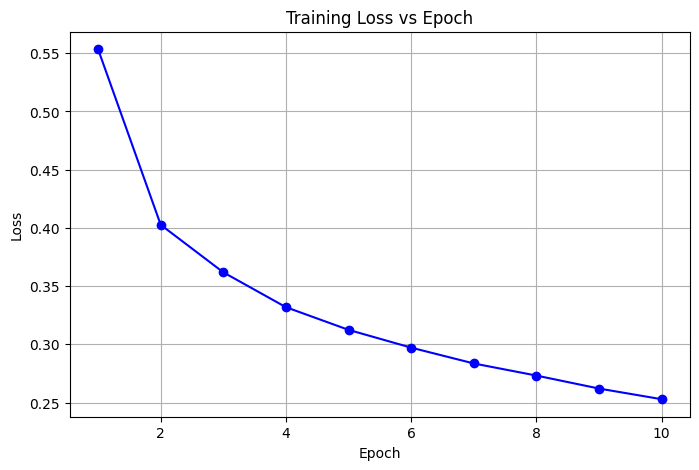

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o', color='b')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()